<a href="https://colab.research.google.com/github/lindsayklu/LindsayKlutts_INFO4670_Spring2025/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [4]:
# write your answer here
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("bread_basket.csv")
data.head(), data.shape

(   transaction           item   date_time   time period_day weekday_weekend
 0            1          Bread  30/10/2016   9:58    morning         weekend
 1            2   Scandinavian  30/10/2016  10:05    morning         weekend
 2            2   Scandinavian  30/10/2016  10:05    morning         weekend
 3            3  Hot chocolate  30/10/2016  10:07    morning         weekend
 4            3            Jam  30/10/2016  10:07    morning         weekend,
 (20507, 6))

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("bread_basket.csv")
data.head(), data.shape

data.dtypes

,0
transaction,int64
item,object
date_time,object
time,object
period_day,object
weekday_weekend,object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [ ]:
# write your answer here
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("bread_basket.csv")
data.head(), data.shape

data.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

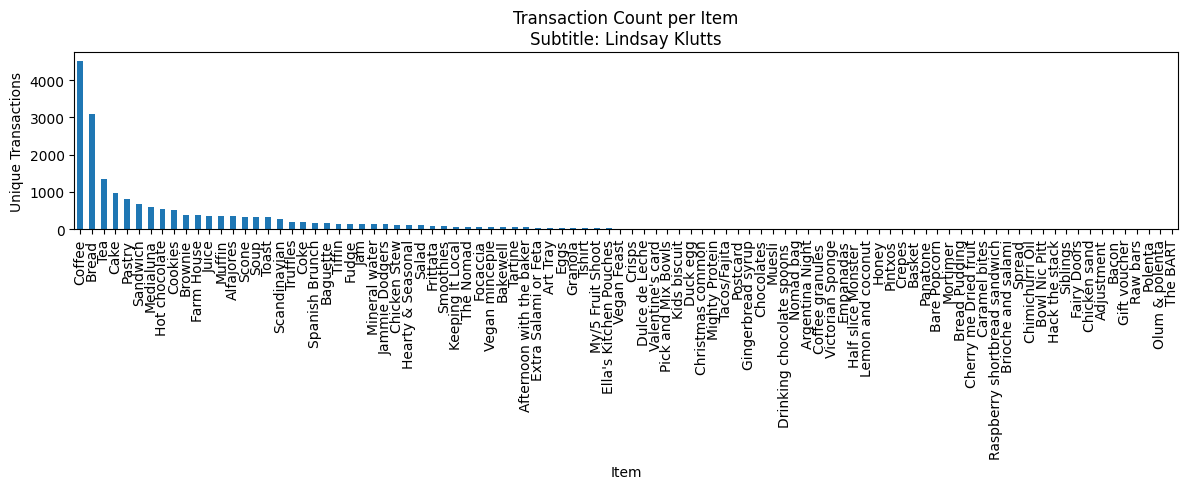

In [ ]:
# c) Bar plot of transaction counts per item
subtitle = "Lindsay Klutts"  # <-- EDIT THIS
item_counts = (
   data.groupby("item")["transaction"]
        .nunique()
       .sort_values(ascending=False)
)
# <-- EDIT THIS
data.columns
ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [ ]:
# write your answer here

items = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]

(
    data[data['item'].isin(items)]
        .groupby('item')['transaction']
        .nunique()
)

,transaction
item,
Alfajores,344
Chicken Stew,123
Coffee,4528
Juice,365
Tea,1350


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [ ]:
# write your answer here
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

transactions = (
    data.groupby("transaction")["item"]
        .apply(list)
        .tolist()
)

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
onehot = pd.DataFrame(te_array, columns=te.columns_)
onehot.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [6]:
# write your answer here
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

transactions = (
    data.groupby("transaction")["item"]
        .apply(list)
        .tolist()
)

te = TransactionEncoder()
onehot_array = te.fit(transactions).transform(transactions)
onehot = pd.DataFrame(onehot_array, columns=te.columns_)

frequent_itemsets = fpgrowth(
    onehot,
    min_support=0.01,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.4
)

rules[['antecedents','consequents','support','confidence','lift']] \
    .sort_values('confidence', ascending=False)

,antecedents,consequents,support,confidence,lift
13,(Toast),(Coffee),0.023666,0.704403,1.472431
15,(Spanish Brunch),(Coffee),0.010882,0.598837,1.251766
4,(Medialuna),(Coffee),0.035182,0.569231,1.189878
3,(Pastry),(Coffee),0.047544,0.552147,1.154168
11,(Alfajores),(Coffee),0.019651,0.540698,1.130235
5,(Juice),(Coffee),0.020602,0.534247,1.116750
10,(Sandwich),(Coffee),0.038246,0.532353,1.112792
7,(Cake),(Coffee),0.054728,0.526958,1.101515
14,(Scone),(Coffee),0.018067,0.522936,1.093107
1,(Cookies),(Coffee),0.028209,0.518447,1.083723


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

Lift > 1 which indicates a positive association between bred and coffee and cake. bread is more likely to be purchased when coffee and cake are both bought together. The support for coffee, cake, and bread together is .010037 and confidence reads as .429864